In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, types
from sqlalchemy import text 

In [32]:
from dotenv import dotenv_values

config = dotenv_values()

pg_user = config['POSTGRES_USER'] 
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [33]:
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

In [34]:
engine = create_engine(url, echo=False)

In [35]:
my_schema = 'team_1' 

with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {my_schema};'))

In [36]:
df_fitbit = pd.read_sql(sql=text('SELECT * FROM fitbit_summary;'), con=engine)
df_fitbit

,id,age,age_group,gender,bmi,avg_rmssd,avg_stress_score,avg_sleep_points_percentage,avg_calories,avg_distance,avg_bpm,avg_lightly_active_minutes,avg_moderately_active_minutes,avg_very_active_minutes,avg_sedentary_minutes,avg_sleep_duration,avg_sleep_efficiency,avg_steps,data_inputs
0,1,<30,young adults,male,<19,100.409677,76.193548,79.467742,2393.338710,6904.880645,70.725806,142.919355,30.532258,34.209677,677.741935,9.188710,93.241935,9363.516129,62
1,2,>=30,adults,female,<19,26.042625,75.612500,75.037500,2223.562500,11761.810000,83.487500,320.400000,38.700000,34.612500,553.700000,7.975000,94.187500,16946.600000,80
2,3,>=30,adults,female,22.0,24.678108,70.364865,74.567568,1465.216216,4227.105405,73.878378,297.459459,2.040541,0.972973,593.391892,8.697297,91.675676,6815.689189,74
3,4,>=30,adults,male,24.0,32.231455,52.072727,55.690909,2153.709091,4300.123636,77.509091,78.690909,21.763636,32.581818,715.927273,9.172727,94.981818,6262.309091,55
4,5,>=30,adults,female,>=25,23.696667,54.523810,56.047619,2173.000000,5193.652381,75.214286,240.142857,15.000000,7.023810,755.785714,6.919048,95.119048,7592.619048,42
5,6,>=30,adults,female,20.0,24.910000,75.275862,80.287356,1818.712644,4457.718391,77.218391,231.413793,6.735632,3.919540,746.275862,7.422989,97.379310,6410.839080,87
6,7,<30,young adults,male,24.0,25.250476,76.206349,85.301587,2775.603175,4636.847619,90.349206,153.793651,33.015873,26.174603,758.031746,7.633333,97.253968,6324.365079,63
7,8,<30,young adults,female,21.0,37.017963,53.851852,52.629630,2258.796296,6273.325926,79.333333,244.685185,14.370370,12.537037,717.407407,6.629630,96.981481,8564.388889,54
8,9,<30,young adults,male,>=30,35.063462,16.730769,16.538462,3050.269231,3489.376923,73.961538,41.884615,11.269231,52.192308,767.884615,8.942308,91.500000,4917.423077,26
9,10,<30,young adults,male,19.0,31.734746,73.847458,84.084746,2158.406780,4972.666102,80.152542,216.779661,5.610169,5.474576,731.932203,7.613559,96.338983,7249.847458,59


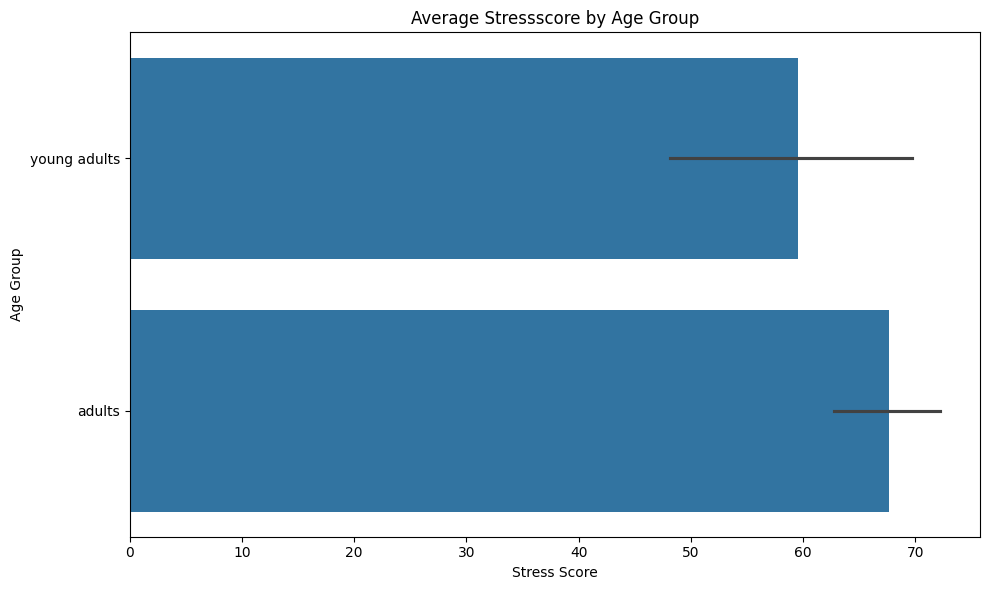

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_fitbit, x='avg_stress_score', y='age_group', orient='h')
plt.title('Average Stressscore by Age Group')
plt.xlabel('Stress Score')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

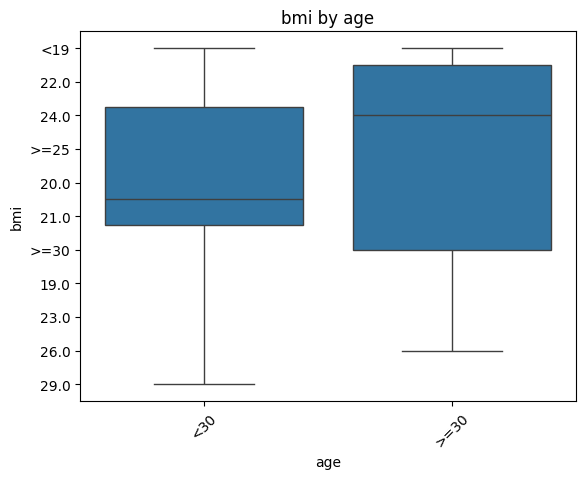

In [38]:
sns.boxplot(data=df_fitbit, x='age', y='bmi')
plt.title('bmi by age')
plt.xlabel('age')
plt.ylabel('bmi')
plt.xticks(rotation=45)
plt.show()

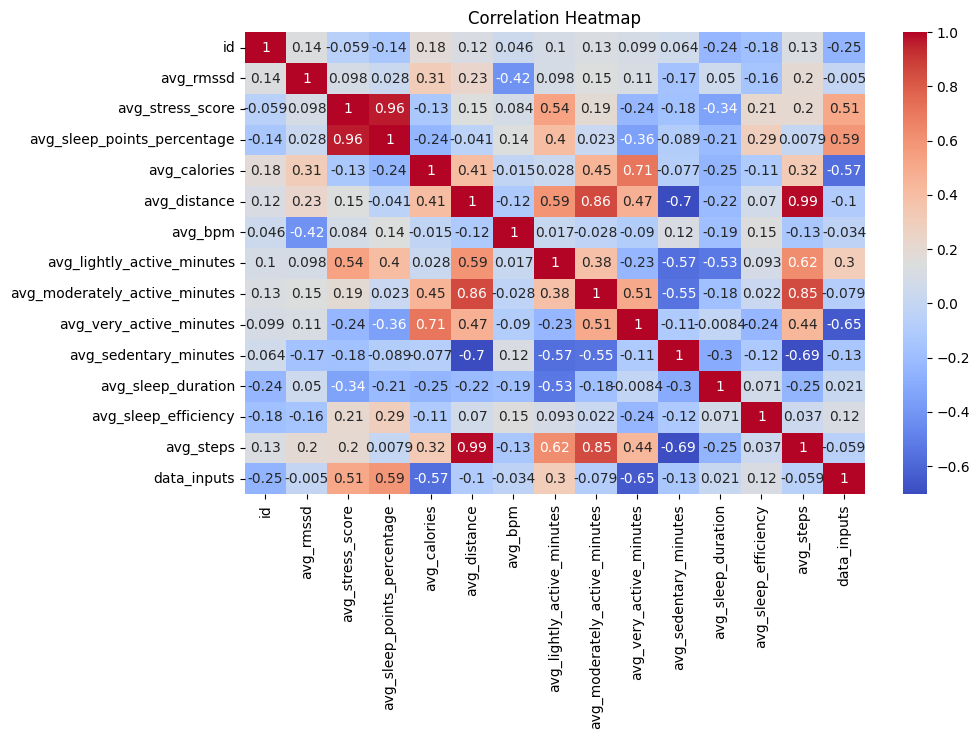

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(df_fitbit.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

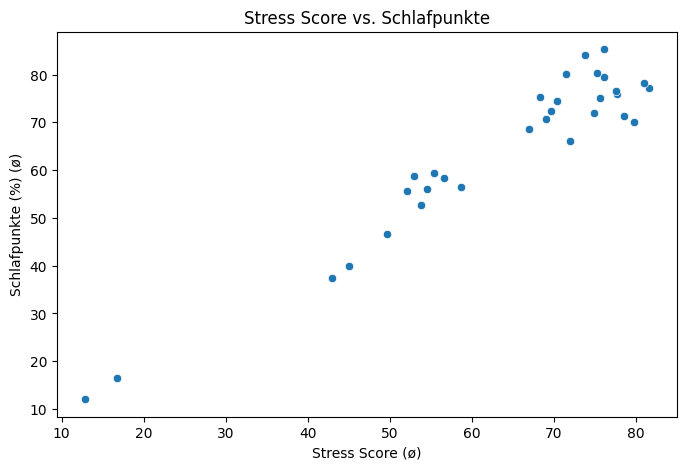

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fitbit, x="avg_stress_score", y="avg_sleep_points_percentage")
plt.title("Stress Score vs. Schlafpunkte")
plt.xlabel("Stress Score (ø)")
plt.ylabel("Schlafpunkte (%) (ø)")
plt.show()


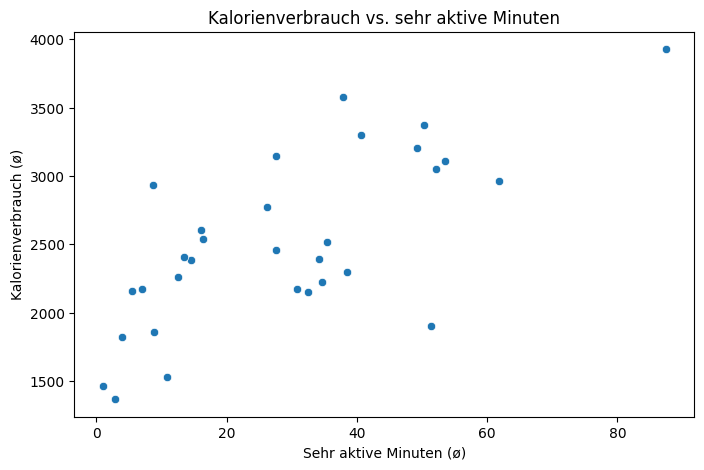

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fitbit, x="avg_very_active_minutes", y="avg_calories")
plt.title("Kalorienverbrauch vs. sehr aktive Minuten")
plt.xlabel("Sehr aktive Minuten (ø)")
plt.ylabel("Kalorienverbrauch (ø)")
plt.show()


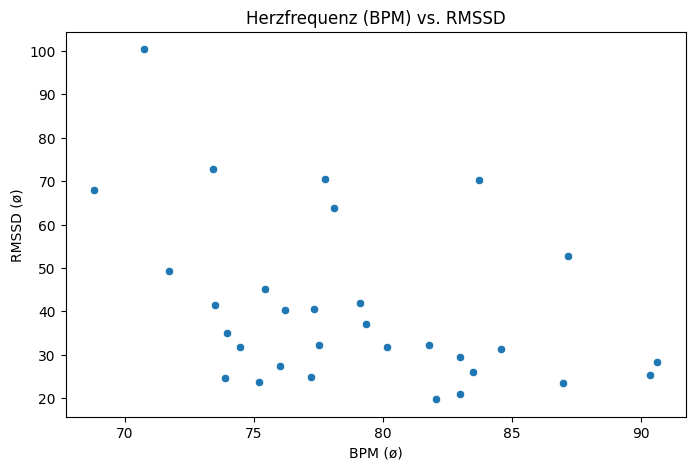

In [42]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fitbit, x="avg_bpm", y="avg_rmssd")
plt.title("Herzfrequenz (BPM) vs. RMSSD")
plt.xlabel("BPM (ø)")
plt.ylabel("RMSSD (ø)")
plt.show()


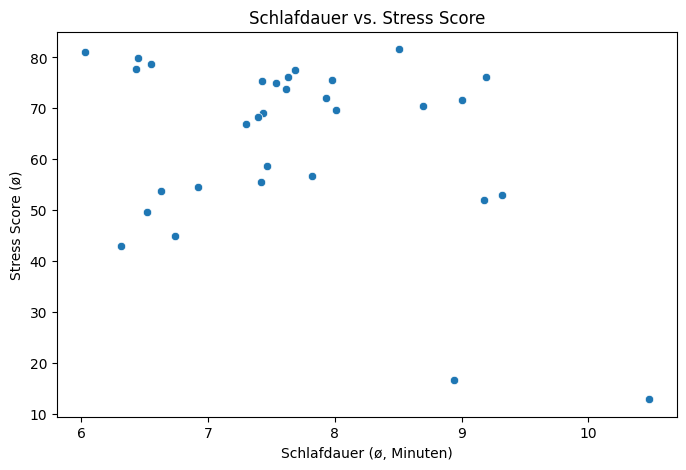

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fitbit, x="avg_sleep_duration", y="avg_stress_score")
plt.title("Schlafdauer vs. Stress Score")
plt.xlabel("Schlafdauer (ø, Minuten)")
plt.ylabel("Stress Score (ø)")
plt.show()


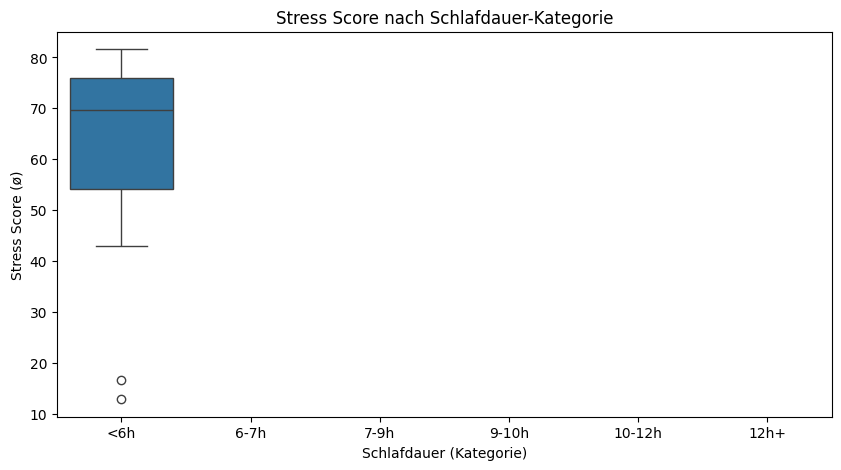

In [44]:
# Schlafdauer kategorisieren
df_fitbit["sleep_cat"] = pd.cut(df_fitbit["avg_sleep_duration"], bins=[0, 360, 420, 540, 600, 720, 1000],
                         labels=["<6h", "6-7h", "7-9h", "9-10h", "10-12h", "12h+"])

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_fitbit, x="sleep_cat", y="avg_stress_score")
plt.title("Stress Score nach Schlafdauer-Kategorie")
plt.xlabel("Schlafdauer (Kategorie)")
plt.ylabel("Stress Score (ø)")
plt.show()


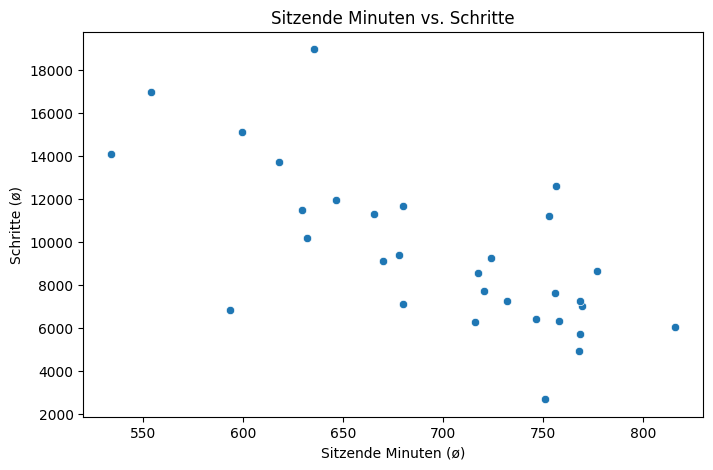

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fitbit, x="avg_sedentary_minutes", y="avg_steps")
plt.title("Sitzende Minuten vs. Schritte")
plt.xlabel("Sitzende Minuten (ø)")
plt.ylabel("Schritte (ø)")
plt.show()


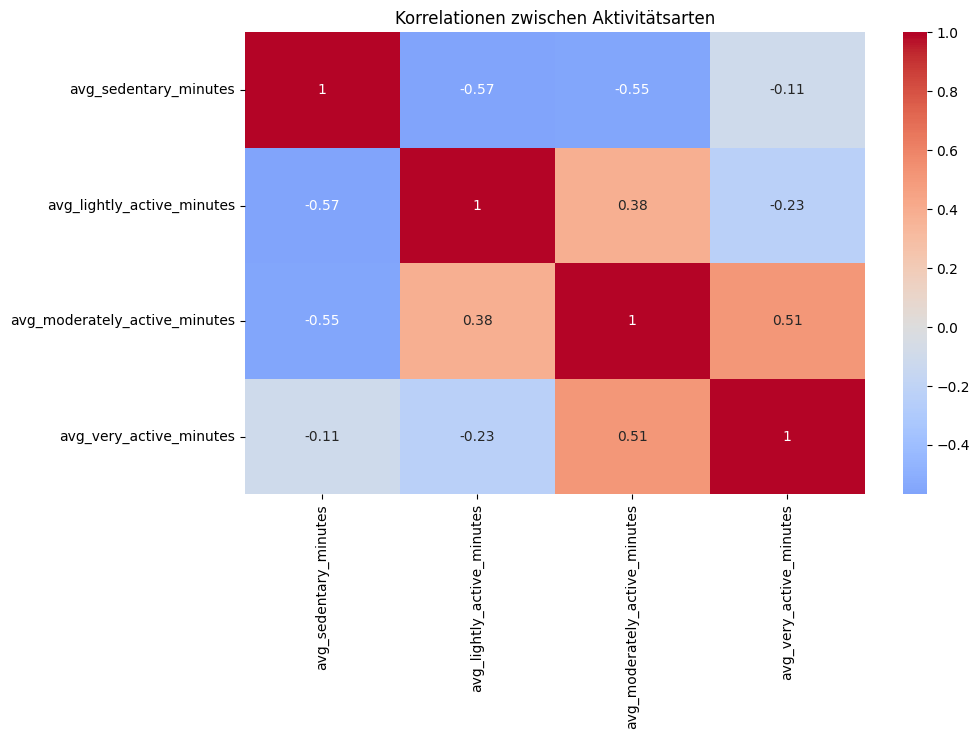

In [46]:
plt.figure(figsize=(10, 6))
activity_vars = [
    "avg_sedentary_minutes", "avg_lightly_active_minutes",
    "avg_moderately_active_minutes", "avg_very_active_minutes"
]

sns.heatmap(df_fitbit[activity_vars].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Korrelationen zwischen Aktivitätsarten")
plt.show()

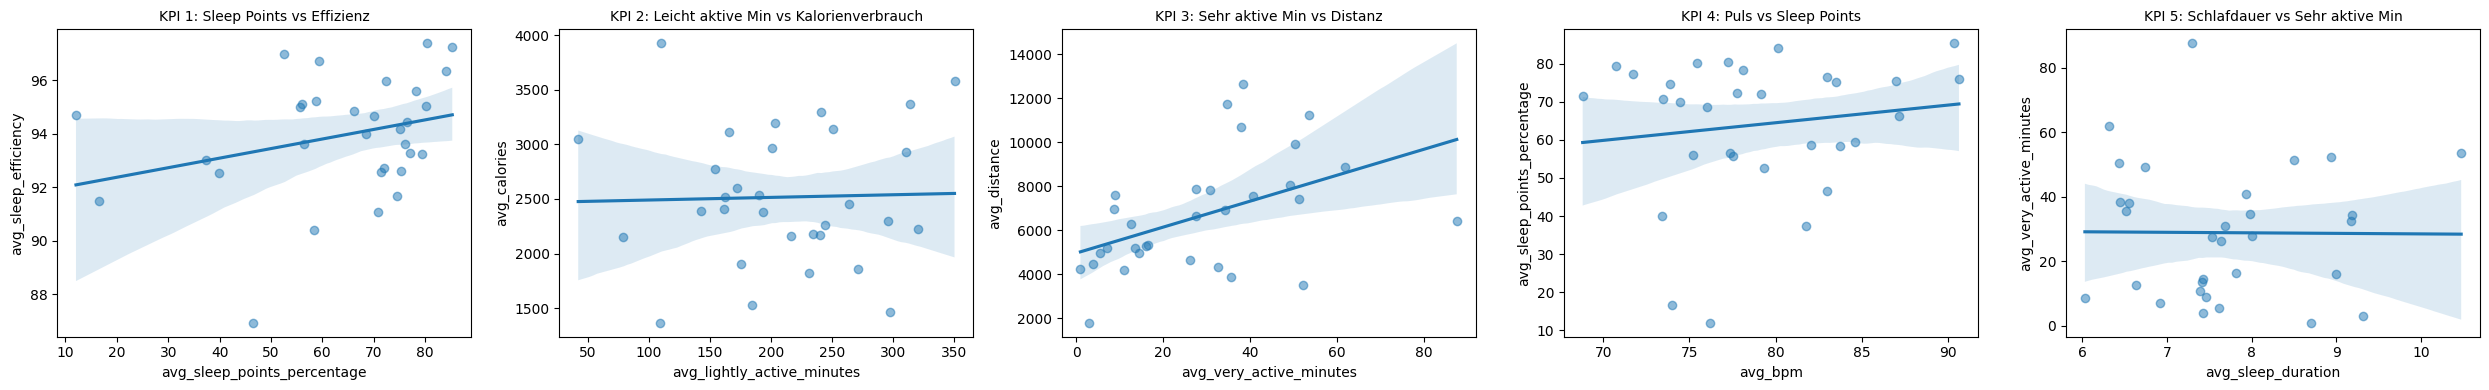

In [47]:

# Liste der KPIs mit Variablenpaaren und Text
kpis = [
    ("avg_sleep_points_percentage", "avg_sleep_efficiency", "KPI 1: Sleep Points vs Effizienz"),
    ("avg_lightly_active_minutes", "avg_calories", "KPI 2: Leicht aktive Min vs Kalorienverbrauch"),
    ("avg_very_active_minutes", "avg_distance", "KPI 3: Sehr aktive Min vs Distanz"),
    ("avg_bpm", "avg_sleep_points_percentage", "KPI 4: Puls vs Sleep Points"),
    ("avg_sleep_duration", "avg_very_active_minutes", "KPI 5: Schlafdauer vs Sehr aktive Min")
]

# Plot-Setup
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for ax, (x_var, y_var, title) in zip(axes, kpis):
    sns.regplot(data=df_fitbit, x=x_var, y=y_var, ax=ax, scatter_kws={'alpha':0.5})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)

plt.tight_layout()
plt.show()

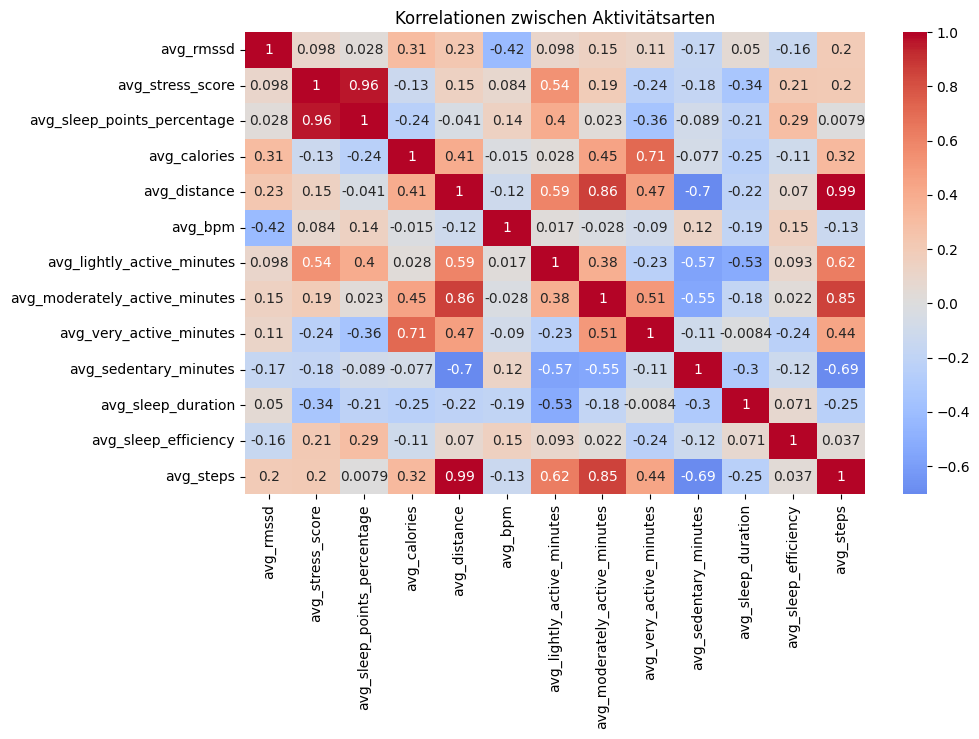

In [48]:
plt.figure(figsize=(10, 6))
activity_vars = [
    "avg_rmssd", "avg_stress_score", "avg_sleep_points_percentage", "avg_calories", "avg_distance", "avg_bpm", "avg_lightly_active_minutes",
    "avg_moderately_active_minutes", "avg_very_active_minutes",  "avg_sedentary_minutes", "avg_sleep_duration", "avg_sleep_efficiency", "avg_steps"
]

sns.heatmap(df_fitbit[activity_vars].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Korrelationen zwischen Aktivitätsarten")
plt.show()

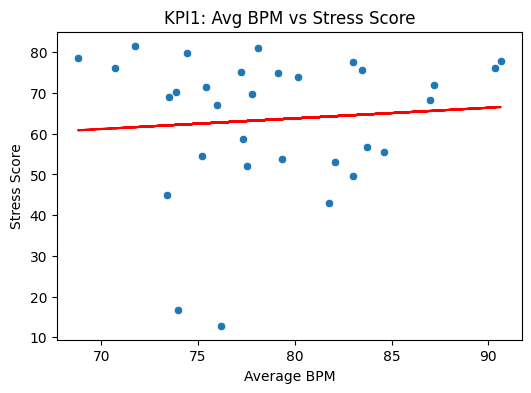

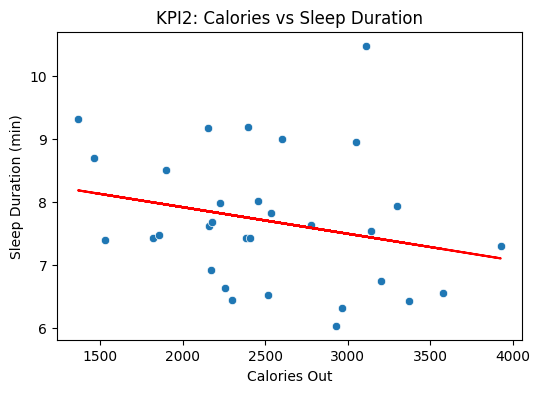

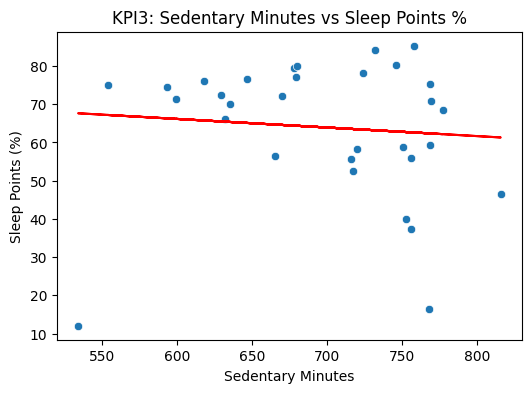

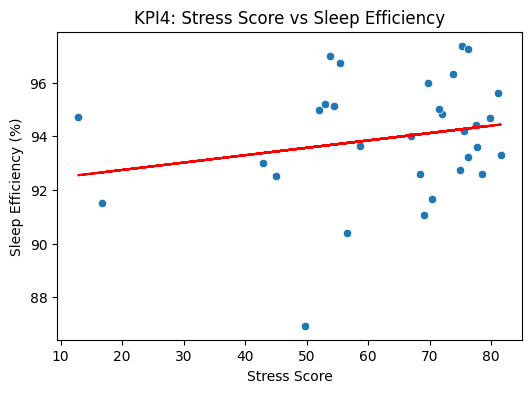

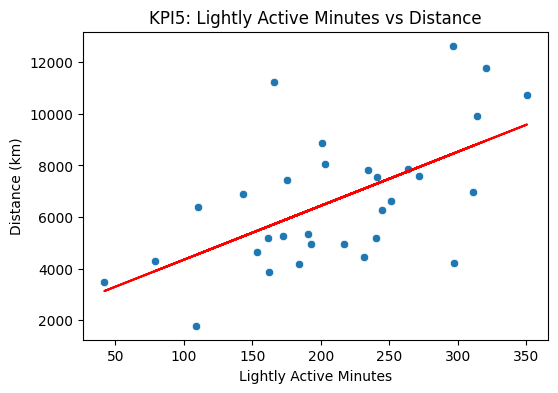

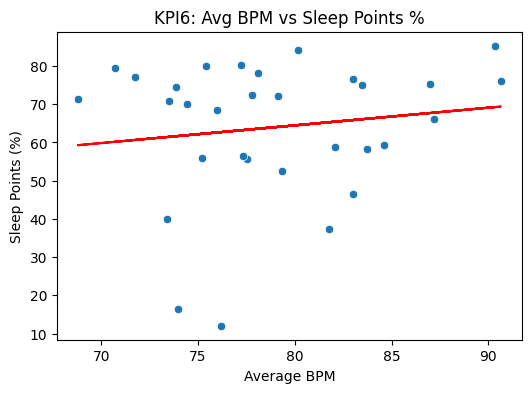

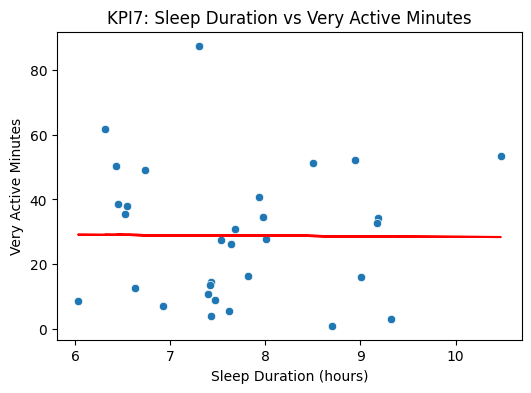

In [49]:

# KPI1: avg_bpm vs avg_stress_score
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_bpm', y='avg_stress_score', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_bpm'], df_fitbit['avg_stress_score'], 1)
plt.plot(df_fitbit['avg_bpm'], m*df_fitbit['avg_bpm'] + b, color='red')
plt.title('KPI1: Avg BPM vs Stress Score')
plt.xlabel('Average BPM')
plt.ylabel('Stress Score')
plt.show()

# KPI2: avg_calories vs avg_sleep_duration
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_calories', y='avg_sleep_duration', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_calories'], df_fitbit['avg_sleep_duration'], 1)
plt.plot(df_fitbit['avg_calories'], m*df_fitbit['avg_calories'] + b, color='red')
plt.title('KPI2: Calories vs Sleep Duration')
plt.xlabel('Calories Out')
plt.ylabel('Sleep Duration (min)')
plt.show()

# KPI3: avg_sedentary_minutes vs avg_sleep_points_percentage
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_sedentary_minutes', y='avg_sleep_points_percentage', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_sedentary_minutes'], df_fitbit['avg_sleep_points_percentage'], 1)
plt.plot(df_fitbit['avg_sedentary_minutes'], m*df_fitbit['avg_sedentary_minutes'] + b, color='red')
plt.title('KPI3: Sedentary Minutes vs Sleep Points %')
plt.xlabel('Sedentary Minutes')
plt.ylabel('Sleep Points (%)')
plt.show()

# KPI4: avg_stress_score vs avg_sleep_efficiency
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_stress_score', y='avg_sleep_efficiency', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_stress_score'], df_fitbit['avg_sleep_efficiency'], 1)
plt.plot(df_fitbit['avg_stress_score'], m*df_fitbit['avg_stress_score'] + b, color='red')
plt.title('KPI4: Stress Score vs Sleep Efficiency')
plt.xlabel('Stress Score')
plt.ylabel('Sleep Efficiency (%)')
plt.show()

# KPI5: avg_lightly_active_minutes vs avg_distance
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_lightly_active_minutes', y='avg_distance', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_lightly_active_minutes'], df_fitbit['avg_distance'], 1)
plt.plot(df_fitbit['avg_lightly_active_minutes'], m*df_fitbit['avg_lightly_active_minutes'] + b, color='red')
plt.title('KPI5: Lightly Active Minutes vs Distance')
plt.xlabel('Lightly Active Minutes')
plt.ylabel('Distance (km)')
plt.show()

# KPI6: avg_bpm vs avg_sleep_points_percentage
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_bpm', y='avg_sleep_points_percentage', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_bpm'], df_fitbit['avg_sleep_points_percentage'], 1)
plt.plot(df_fitbit['avg_bpm'], m*df_fitbit['avg_bpm'] + b, color='red')
plt.title('KPI6: Avg BPM vs Sleep Points %')
plt.xlabel('Average BPM')
plt.ylabel('Sleep Points (%)')
plt.show()

# KPI7: avg_sleep_duration vs avg_very_active_minutes
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_sleep_duration', y='avg_very_active_minutes', data=df_fitbit)
m, b = np.polyfit(df_fitbit['avg_sleep_duration'], df_fitbit['avg_very_active_minutes'], 1)
plt.plot(df_fitbit['avg_sleep_duration'], m*df_fitbit['avg_sleep_duration'] + b, color='red')
plt.title('KPI7: Sleep Duration vs Very Active Minutes')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Very Active Minutes')
plt.show()


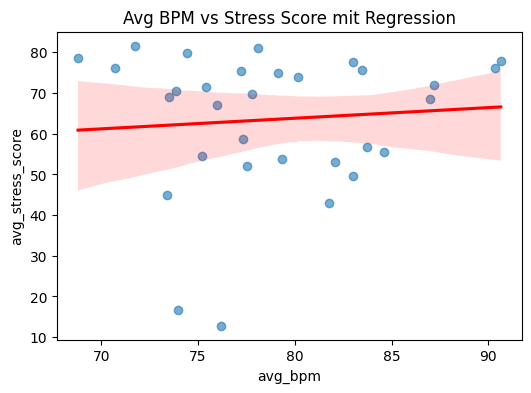

In [50]:
plt.figure(figsize=(6,4))
sns.regplot(x='avg_bpm', y='avg_stress_score', data=df_fitbit, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Avg BPM vs Stress Score mit Regression')
plt.show()


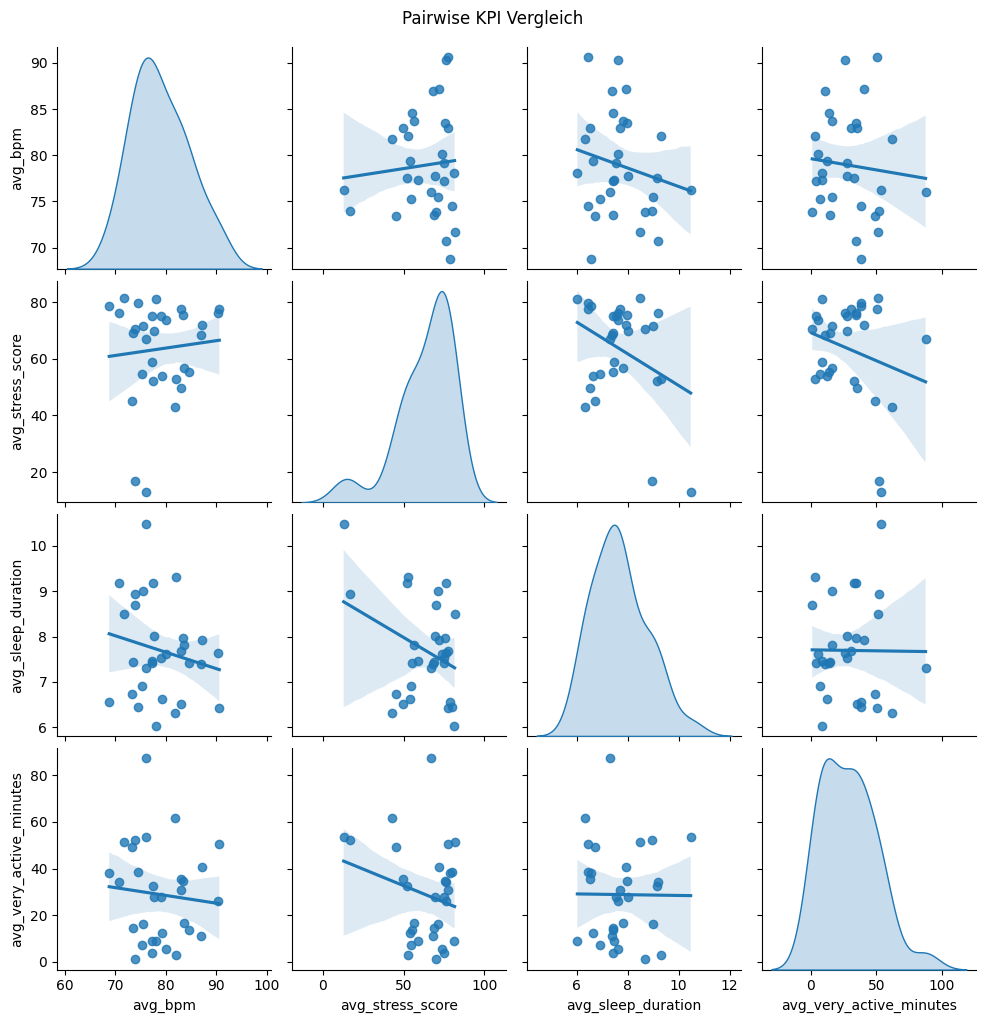

In [51]:
sns.pairplot(df_fitbit[['avg_bpm','avg_stress_score','avg_sleep_duration','avg_very_active_minutes']], 
             kind='reg', diag_kind='kde')
plt.suptitle("Pairwise KPI Vergleich", y=1.02)
plt.show()


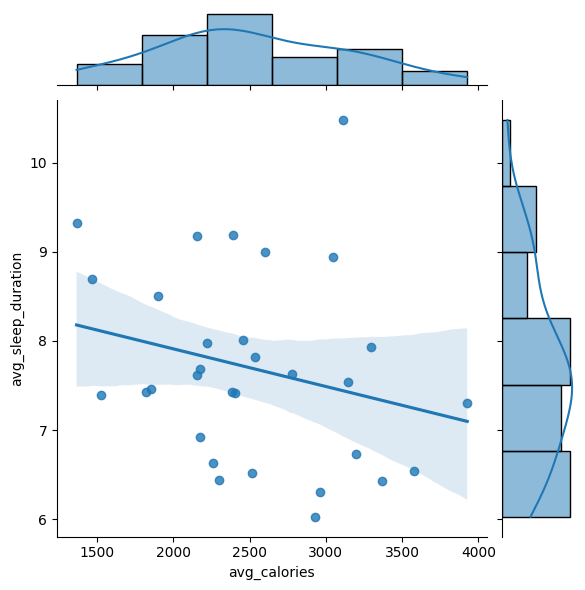

In [52]:
sns.jointplot(x='avg_calories', y='avg_sleep_duration', data=df_fitbit, kind='reg', height=6)
plt.show()
